# Método da Bisseção

In [11]:
%load_ext autoreload
%autoreload 2

import sys
from IPython.display import display
import matplotlib.pyplot as plt

caminho = r"C:\Users\PAIVA\Documents\programação\projeto_circuitos_gq1"

if caminho not in sys.path:
    sys.path.append(caminho)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
from pacote_numerico.bissecao import metodo_bissecao

f_circuito = lambda i: -i**3 - 2*i + 10

dados_para_tabela_bis, raiz_aprox, k = metodo_bissecao(f_circuito, 1, 2, 1e-6, 100)
print(raiz_aprox)
print(k)
display(dados_para_tabela_bis)

1.847419261932373
20


,Iteração,x_novo,Erro
0,1,1.500000,5.000000e-01
1,2,1.750000,2.500000e-01
2,3,1.875000,1.250000e-01
3,4,1.812500,6.250000e-02
4,5,1.843750,3.125000e-02
5,6,1.859375,1.562500e-02
6,7,1.851562,7.812500e-03
7,8,1.847656,3.906250e-03
8,9,1.845703,1.953125e-03
9,10,1.846680,9.765625e-04


# Método das Secantes

In [13]:
from pacote_numerico.secantes import metodo_secantes

dados_para_tabela_sec, raiz_aprox, k = metodo_secantes(f_circuito, 1, 2, e1=1e-6, e2=1e-6)
print(raiz_aprox)
print(k)
display(dados_para_tabela_sec)

1.8474190378106463
5


,Iteração,x0,x1,x_novo,f(x_novo),erro_1,erro2
0,1,1.000000,2.000000,1.777778,8.257888e-01,8.257888e-01,2.222222e-01
1,2,2.000000,1.777778,1.842718,5.740758e-02,5.740758e-02,6.494067e-02
2,3,1.777778,1.842718,1.847570,-1.851621e-03,1.851621e-03,4.851871e-03
3,4,1.842718,1.847570,1.847419,3.946011e-06,3.946011e-06,1.516022e-04
4,5,1.847570,1.847419,1.847419,2.703135e-10,2.703135e-10,3.223942e-07


# Método Newton-Raphson

In [14]:
from pacote_numerico.newton_raphson import newton_raphson

derivada_f_circuito = lambda i: -3*i**2 - 2

dados_para_tabela_new, raiz_aprox, k = newton_raphson(f_circuito, derivada_f_circuito, 1.5, 1e-6, 1e-6)
print(raiz_aprox)
print(k)
display(dados_para_tabela_new)


1.8474190378340813
4


,Iteração,X_novo,f(x),Erro
0,1,1.914286,8.434519e-01,0.414286
1,2,1.849372,2.392552e-02,0.064914
2,3,1.847421,2.112015e-05,0.001951
3,4,1.847419,1.650591e-11,0.000002


# Comparações de convergência

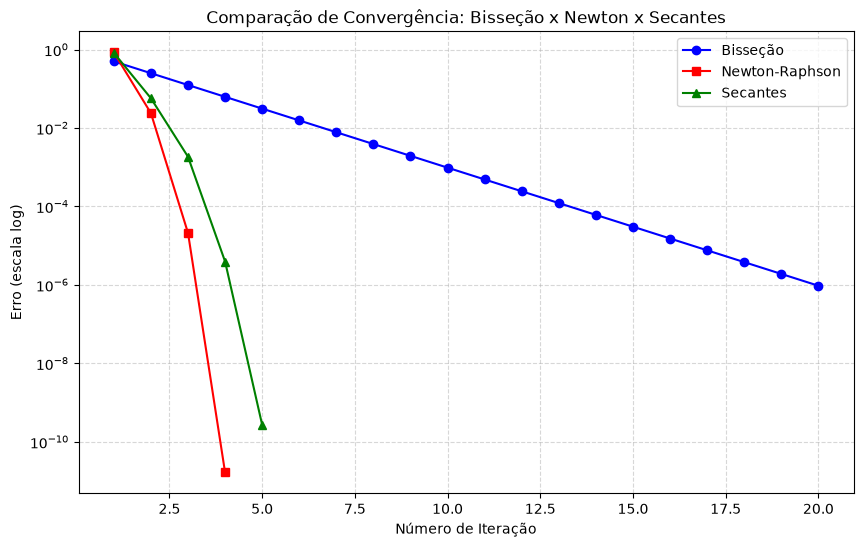

In [15]:
plt.figure(figsize=(10,6))

plt.plot(dados_para_tabela_bis['Iteração'], dados_para_tabela_bis['Erro'], marker='o', color='blue', label='Bisseção')
plt.plot(dados_para_tabela_new['Iteração'], dados_para_tabela_new['f(x)'], marker='s', color='red', label='Newton-Raphson')
plt.plot(dados_para_tabela_sec['Iteração'], dados_para_tabela_sec['erro_1'], marker='^', color='green', label="Secantes")

plt.yscale('log')
plt.xlabel('Número de Iteração')
plt.ylabel('Erro (escala log)')
plt.title('Comparação de Convergência: Bisseção x Newton x Secantes')
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.legend()
plt.show()